In [1]:
pip install dbfread pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
from dbfread import DBF
import pandas as pd

ruta_dbf = "../datos/crudos/bd_eod_2017_dbf/TVIAJE.DBF"

tabla = DBF(ruta_dbf, load=True, encoding="latin1")
df = pd.DataFrame(iter(tabla))

print(df.head())
print(df.columns.tolist())

   ID_VIA  ID_SOC P5_3 N_VIA P5_6 P5_7_6 P5_7_7 DTO_ORIGEN P5_9_1 P5_9_2  ...  \
0       1       1    1    01   01    015     09        001     06     50  ...   
1       2       1    1    02   11    015     09        001     17     50  ...   
2       3       1    2    01   11    015     09        001     06     50  ...   
3       4       1    2    02   11    015     09        001     17     50  ...   
4       5       3    1    01   01    015     09        001     07     40  ...   

  P5_27_6 P5_27_7 P5_27_8 ESTRATO FACTOR UPM_DIS EST_DIS TLOC SEXO EDAD  
0                               2    111   00001    0010    1    1   29  
1                               2    111   00001    0010    1    1   29  
2                               2    111   00001    0010    1    1   29  
3                               2    111   00001    0010    1    1   29  
4       2       2       2       2    111   00001    0010    1    2   28  

[5 rows x 82 columns]
['ID_VIA', 'ID_SOC', 'P5_3', 'N_VIA', 'P5_6', 

In [8]:

tabla = DBF(ruta_dbf, load=True, encoding="latin1")
df = pd.DataFrame(iter(tabla))

# Normalizar nombres
df.columns = [c.strip().upper() for c in df.columns]

# Columnas que te interesan
cols = [
    "P5_9_1","P5_9_2",
    "P5_10_1","P5_10_2",
    "P5_11A",
    "P5_12_6","P5_12_7",
    "P5_7_6", "P5_7_7",
    "DTO_ORIGEN","DTO_DEST",
    "EDAD","SEXO"
]

df = df[cols].copy()

print(df.head())

  P5_9_1 P5_9_2 P5_10_1 P5_10_2 P5_11A P5_12_6 P5_12_7 P5_7_6 P5_7_7  \
0     06     50      07      00     11     015      09    015     09   
1     17     50      18      00     01     015      09    015     09   
2     06     50      07      00     11     015      09    015     09   
3     17     50      18      00     01     015      09    015     09   
4     07     40      08      00     02     017      09    015     09   

  DTO_ORIGEN DTO_DEST EDAD SEXO  
0        001      001   29    1  
1        001      001   29    1  
2        001      001   29    1  
3        001      001   29    1  
4        001      004   28    2  


In [9]:
# Valores no válidos típicos en encuestas
invalid_values = [99, 999, 9999, -1]

df.replace(invalid_values, pd.NA, inplace=True)

# Convertir a numérico
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [12]:
df["INICIO_MIN"] = df["P5_9_1"] * 60 + df["P5_9_2"]
df["FIN_MIN"] = df["P5_10_1"] * 60 + df["P5_10_2"]

df["TIEMPO_CALC"] = df["FIN_MIN"] - df["INICIO_MIN"]

# Ajuste si cruza medianoche
df.loc[df["TIEMPO_CALC"] < 0, "TIEMPO_CALC"] += 24*60

In [13]:
# Comparar tiempos
df["ERROR_TIEMPO"] = df["TIEMPO_MIN"] - df["TIEMPO_CALC"]

print(df["ERROR_TIEMPO"].describe())

count    531594.000000
mean        722.799495
std         315.132491
min        -780.000000
25%         470.000000
50%         730.000000
75%         930.000000
max        6039.000000
Name: ERROR_TIEMPO, dtype: float64


In [14]:
print(df["P5_12_6"].value_counts(dropna=False))
print(df["P5_12_7"].value_counts(dropna=False))

P5_12_6
7      45674
33     39190
5      32400
15     27560
58     24810
       ...  
182        1
153        1
174        1
131        1
142        1
Name: count, Length: 131, dtype: int64
P5_12_7
9     265472
15    258456
13      3855
99      2213
17       591
21       325
22       179
29        79
11        78
30        73
12        63
16        62
20        32
14        24
24        23
25        18
27         8
31         8
19         7
3          6
7          4
1          3
28         3
2          3
10         2
4          2
23         2
18         1
32         1
8          1
Name: count, dtype: int64


In [15]:
map_motivo = {
    1: "Oficina",
    2: "Escuela",
    3: "Su hogar",
    4: "Hospital, clínica, consultorio, laboratorio clínico"
}

df["MOTIVO"] = df["P5_12_6"].map(map_motivo)

In [16]:
df_trab = df[df["MOTIVO"] == "Trabajo"].copy()
df_esc = df[df["MOTIVO"] == "Escuela"].copy()

In [18]:
df.groupby("MOTIVO")["TIEMPO_CALC"].describe()

,count,mean,std,min,25%,50%,75%,max
MOTIVO,,,,,,,,
Escuela,15125.0,43.361587,39.584547,0.0,15.0,30.0,60.00,1200.0
"Hospital, clínica, consultorio, laboratorio clínico",7758.0,50.925754,42.316653,0.0,20.0,40.0,65.00,990.0
Oficina,20.0,293.000000,136.700210,0.0,239.0,300.0,359.25,660.0
Su hogar,20938.0,47.148199,37.534426,0.0,20.0,35.0,60.00,660.0


In [19]:
df.groupby(["MOTIVO","SEXO"])["TIEMPO_CALC"].mean()

MOTIVO                                               SEXO
Escuela                                              1        48.963648
                                                     2        37.755820
Hospital, clínica, consultorio, laboratorio clínico  1        56.696137
                                                     2        45.220456
Oficina                                              1       294.666667
                                                     2       291.636364
Su hogar                                             1        50.732594
                                                     2        43.864281
Name: TIEMPO_CALC, dtype: float64

In [22]:
bins = [0,18,30,45,60,100]
labels = ["0-18","19-30","31-45","46-60","60+"]

df["GRUPO_EDAD"] = pd.cut(df["EDAD"], bins=bins, labels=labels)

df.groupby(["MOTIVO","GRUPO_EDAD"])["TIEMPO_CALC"].mean()

/var/folders/hy/fw0kkxsn6sx7mnljbdvgjdk40000gn/T/ipykernel_64830/916233277.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["MOTIVO","GRUPO_EDAD"])["TIEMPO_CALC"].mean()


MOTIVO                                               GRUPO_EDAD
Escuela                                              0-18           31.941283
                                                     19-30          49.672522
                                                     31-45          47.835046
                                                     46-60          45.559843
                                                     60+            35.357063
Hospital, clínica, consultorio, laboratorio clínico  0-18           35.316038
                                                     19-30          57.643881
                                                     31-45          54.673095
                                                     46-60          55.083887
                                                     60+            44.408000
Oficina                                              0-18          359.000000
                                                     19-30         249.000000


In [23]:
od = df.groupby(["DTO_ORIGEN","DTO_DEST"]).size().reset_index(name="N")

In [25]:
od_time = df.groupby(["DTO_ORIGEN","DTO_DEST"])["TIEMPO_CALC"].mean().reset_index()

In [26]:
# Filtrar viajes irreales (> 4 horas)
df = df[df["TIEMPO_CALC"] < 240]

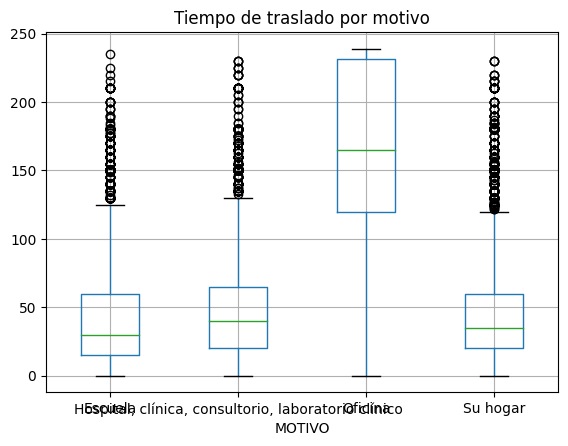

In [27]:
import matplotlib.pyplot as plt

df.boxplot(column="TIEMPO_CALC", by="MOTIVO")
plt.title("Tiempo de traslado por motivo")
plt.suptitle("")
plt.show()